# External import

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import os
from time import time
from datetime import datetime, timedelta
import traceback
import sys

from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import cross_validate
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import *
from tqdm import tqdm

from sklearn.metrics import confusion_matrix

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Personnal import

In [2]:
from ml_get_X_y_groups_timestamps import *
from ml_split_train_test import *
from ml_data_normalization import *
from ml_model_performance_checking import *
from ml_on_demand_survey import *
from ml_feature_selection import *
from ml_data_filtering import *

from computing_parameters import Computing_Parameters
import my_paths

In [3]:
#For Reproducibility
seed_value = 41 
#Report it that number to your experiment tracking system.
#experiment = Experiment(project_name="Classification model") 
#experiment.log_other("random seed",seed_value)

# 1. Set `PYTHONHASHSEED` environment variable at a fixed value: 
import os 
os.environ['PYTHONHASHSEED']=str(seed_value) 
# 2. Set `python` built-in pseudo-random generator at a fixed value: 
import random 
random.seed(seed_value) 
# 3. Set `numpy` pseudo-random generator at a fixed value:
import numpy as np 
np.random.seed(seed_value) 
# 4. Set `tensorflow` pseudo-random generator at a fixed value: 
#import tensorflow as tf tf.set_random_seed(seed_value)
# 5. For layers that introduce randomness like dropout, make sure to set seed values:
#model.add(Dropout(0.25, seed=seed_value))
#6 Configure a new global `tensorflow` session: 
#from keras import backend as K 
#session_conf = tf.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1) 
#sess = tf.Session(graph=tf.get_default_graph(), config=session_conf)
#K.set_session(sess)


# Plot answers distribution

In [4]:
df = get_original_dataframe() # in ml get x and y notebook


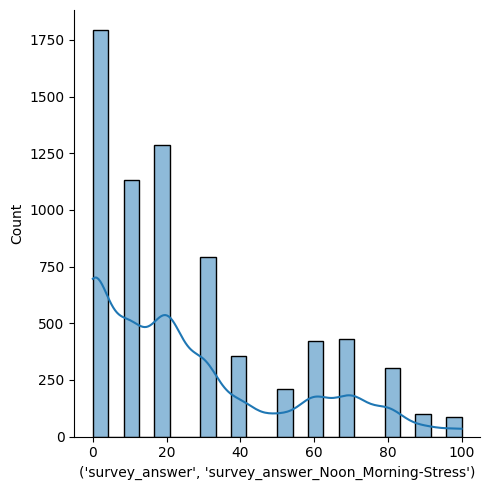

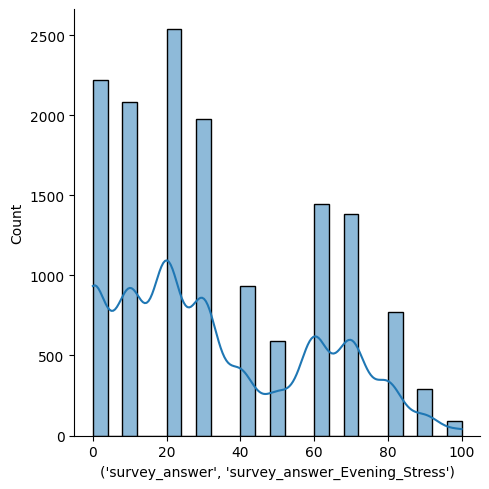

In [5]:
sns.displot(df[("survey_answer", Target_Column.Noon_Morning_Stress.value)], kde=True)
sns.displot(df[("survey_answer", Target_Column.Evening_Afternoone_Stress.value)], kde=True)
plt.show()

# Global variables

In [6]:
selected_random_state = 2022
selected_target_column=Target_Column.Noon_Morning_Stress #  list of posible target values -> for t in Target_Column: print(t)
selected_minimum_threshold_for_target_binarization=10  #The thresholds: it will be 0 if value is less than 10
selected_maximum_threshold_for_target_binarization=90  #The thresholds: it will be 1 if value is more than 90
score_metric = "f1_weighted"

In [7]:
#Let's create a Dataframe to record the results of the models
from sklearn.metrics import confusion_matrix
results = pd.DataFrame({}, columns=['Model', 'TP', 'FP', 'FN', 'TN'])
#at the end run this code to calculate the accuracy and printn the tabel of results
results['Accuracy'] = (results['TP']+results['TN'])/(results['TP']+results['FP']+results['FN']+results['TN'])
results

,Model,TP,FP,FN,TN,Accuracy


# First experimentation : The basis
- Classical 80/20 split train/test
- Standard normalization
- ```clf = SVC(class_weight="balanced")```

In [8]:
# Get X, y
X, y, groups, timestamps = get_X_y_groups_timestamps(
    target_column=selected_target_column,
    minimum_threshold_for_target_binarization=selected_minimum_threshold_for_target_binarization,
    maximum_threshold_for_target_binarization=selected_maximum_threshold_for_target_binarization,
)
# Classical 80/20 split train/test
X_train, X_test, y_train, y_test = get_naively_X_train_X_test_y_train_y_test(
    X=X,
    y=y,
    ratio=0.2,
    stratify=True,
    selected_radom_state=selected_random_state
)
# Standard normalization
X_train, X_test = classic_data_normalization(X_train=X_train, X_test=X_test)
# Create a classifier (support vector classifier) and train it on the train subset
clf = SVC(class_weight="balanced")
fit_time_t1 = time()
clf.fit(X_train, y_train)
fit_time_t2 = time()
print(f"Fit in {round(fit_time_t2 - fit_time_t1, 2)} s")
# Predict on the test subset
y_pred = clf.predict(X_test)


[Eliminate participants with not enought data]
	 UUID 86, 20 lines --> removed participant
	 UUID 88, 8 lines --> removed participant

[Index cleaning] 
	 changes the multi-index of the columns to a simple index 
	 removes the multi-index of the rows 
		 timestamp and uuid becomes new columns

[Drop the unusable columns]
	 Dropped columns (96) : ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_ptp', 'acc_x_sum', 'acc_x_energy', 'acc_x_skewness', 'acc_x_kurtosis', 'acc_x_peaks', 'acc_x_rms', 'acc_x_lineintegral', 'acc_x_n_above_mean', 'acc_x_n_below_mean', 'acc_x_n_sign_changes', 'acc_x_iqr', 'acc_x_iqr_5_95', 'acc_x_pct_5', 'acc_x_pct_95', 'acc_x_entropy', 'acc_x_perm_entropy', 'acc_x_svd_entropy', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_ptp', 'acc_y_sum', 'acc_y_energy', 'acc_y_skewness', 'acc_y_kurtosis', 'acc_y_peaks', 'acc_y_rms', 'acc_y_lineintegral', 'acc_y_n_above_mean', 'acc_y_n_below_mean', 'acc_y_n_sign_changes', 'acc_y_iqr', 'acc_y_iqr_5_95',

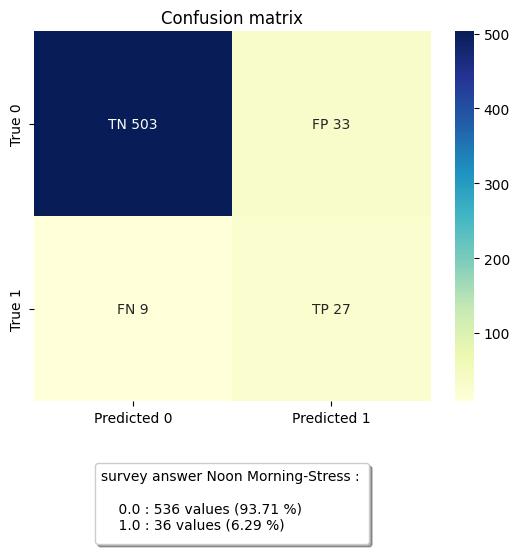

              precision    recall  f1-score   support

         0.0       0.98      0.94      0.96       536
         1.0       0.45      0.75      0.56        36

    accuracy                           0.93       572
   macro avg       0.72      0.84      0.76       572
weighted avg       0.95      0.93      0.93       572



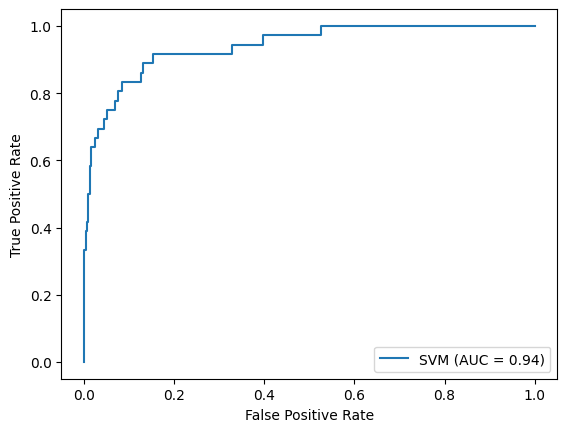

In [9]:
# Check model accurracy
check_confusion_matrix(y=y_test, y_pred=y_pred)
check_classification_report(y=y_test, y_pred=y_pred, print_bla_bla=False, print_as_text=True)
check_roc_auc(estimator=clf, X_test=X_test, y_test=y_test)

#put this code after each model
dtc_cm = confusion_matrix(y_test, y_pred)
tp, fp, fn, tn = [item for sublist in dtc_cm.tolist() for item in sublist]
results.loc[len(results.index)] = ['first basic', tp, fp, fn, tn,0] 

# Second experimentation : Special split train/test
- Groups care 80/20 split train/test (A separation that takes individuals into account and ensures that a participant's data does not end up in the train and test sets)
- Standard normalization
- ```clf = SVC(class_weight="balanced")```

In [10]:
from sklearn.model_selection import StratifiedGroupKFold

# Get X, y
X, y, groups, timestamps = get_X_y_groups_timestamps(
    target_column=selected_target_column,
    minimum_threshold_for_target_binarization=selected_minimum_threshold_for_target_binarization,
    maximum_threshold_for_target_binarization=selected_maximum_threshold_for_target_binarization,
)


# Groups care 80/20 split train/test
X_train, X_test, y_train, y_test, groups_train, groups_test = get_group_cared_X_train_X_test_y_train_y_test(X=X, y=y, groups=groups)
# Separate X and y in the training and test sets taking into account the uuid of the participants as groups. That is, a participant's data will not be able to be found in the training AND test sets.
    
# Standard normalization
X_train, X_test = classic_data_normalization(X_train=X_train, X_test=X_test)
# Create a classifier (support vector classifier) and train it on the train subset
clf = SVC(class_weight="balanced")
fit_time_t1 = time()
clf.fit(X_train, y_train)
fit_time_t2 = time()
print(f"Fit in {round(fit_time_t2 - fit_time_t1, 2)} s")
# Predict on the test subset
y_pred = clf.predict(X_test)


[Eliminate participants with not enought data]
	 UUID 86, 20 lines --> removed participant
	 UUID 88, 8 lines --> removed participant

[Index cleaning] 
	 changes the multi-index of the columns to a simple index 
	 removes the multi-index of the rows 
		 timestamp and uuid becomes new columns

[Drop the unusable columns]
	 Dropped columns (96) : ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_ptp', 'acc_x_sum', 'acc_x_energy', 'acc_x_skewness', 'acc_x_kurtosis', 'acc_x_peaks', 'acc_x_rms', 'acc_x_lineintegral', 'acc_x_n_above_mean', 'acc_x_n_below_mean', 'acc_x_n_sign_changes', 'acc_x_iqr', 'acc_x_iqr_5_95', 'acc_x_pct_5', 'acc_x_pct_95', 'acc_x_entropy', 'acc_x_perm_entropy', 'acc_x_svd_entropy', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_ptp', 'acc_y_sum', 'acc_y_energy', 'acc_y_skewness', 'acc_y_kurtosis', 'acc_y_peaks', 'acc_y_rms', 'acc_y_lineintegral', 'acc_y_n_above_mean', 'acc_y_n_below_mean', 'acc_y_n_sign_changes', 'acc_y_iqr', 'acc_y_iqr_5_95',

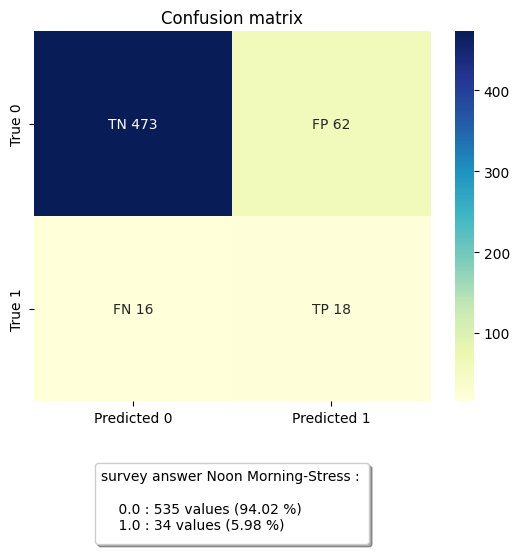

              precision    recall  f1-score   support

         0.0       0.97      0.88      0.92       535
         1.0       0.23      0.53      0.32        34

    accuracy                           0.86       569
   macro avg       0.60      0.71      0.62       569
weighted avg       0.92      0.86      0.89       569



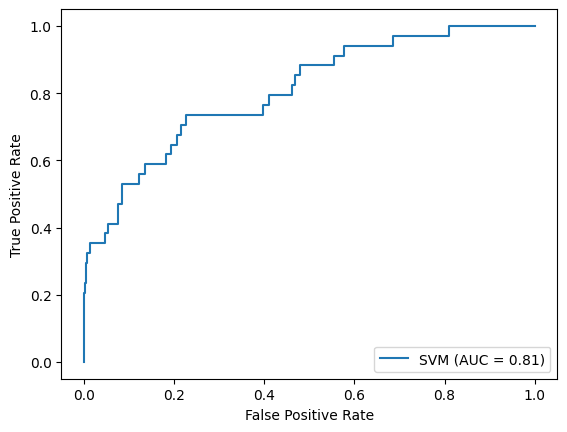

In [11]:
# Check model accurracy
check_confusion_matrix(y=y_test, y_pred=y_pred)
check_classification_report(y=y_test, y_pred=y_pred, print_bla_bla=False, print_as_text=True)
check_roc_auc(estimator=clf, X_test=X_test, y_test=y_test)

#put this code after each model
dtc_cm = confusion_matrix(y_test, y_pred)
tp, fp, fn, tn = [item for sublist in dtc_cm.tolist() for item in sublist]
results.loc[len(results.index)] = ['second Special split train/test', tp, fp, fn, tn,0] 

# Third experimentation : SVM Hyperparameter Tuning

- Groups care 80/20 split train/test (A separation that takes individuals into account and ensures that a participant's data does not end up in the train and test sets)
- Standard normalization
- ```clf = SVC(class_weight="balanced")``` + Hyperparameter Tuning : ```scoring_metric="f1_weighted"``` , ```inner_CV=StratifiedGroupKFold(n_splits=5)```

In [12]:
# Get X, y
X, y, groups, timestamps = get_X_y_groups_timestamps(
    target_column=selected_target_column,
    minimum_threshold_for_target_binarization=selected_minimum_threshold_for_target_binarization,
    maximum_threshold_for_target_binarization=selected_maximum_threshold_for_target_binarization,
)
# Groups care 80/20 split train/test
X_train, X_test, y_train, y_test, groups_train, groups_test = get_group_cared_X_train_X_test_y_train_y_test(X=X, y=y, groups=groups)
# Standard normalization
X_train, X_test = classic_data_normalization(X_train=X_train, X_test=X_test)

# Hyperparameters optimisation and classifier training
param_grid = {
        "kernel" : ["rbf"],
        "C" : [1, 2, 4, 8, 16, 32, 64, 128],
        "gamma" : ['auto', 'scale', 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001],
        "class_weight" : ["balanced"],
        "random_state" : [selected_random_state]
}
inner_CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=selected_random_state)
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring=score_metric,
    cv=inner_CV,
    verbose=3,
    n_jobs=-1,
)
fit_time_t1 = time()
grid.fit(X=X_train, y=y_train, groups=groups_train)
fit_time_t2 = time()
print("\n[GridSearch results]")
print(f"\t Fit in {round(fit_time_t2 - fit_time_t1, 2)} s")
print(f"\t Train best score : {round(grid.best_score_, 3)} ({grid.scoring})")
print(f"\t Best parameters set for {grid.estimator} :")
best_parameters = grid.best_estimator_.get_params()
for param_name in sorted(param_grid.keys()):
    print("\t\t %s : %r" % (param_name, best_parameters[param_name]))
# Predict on the test subset
y_pred = grid.best_estimator_.predict(X_test)


[Eliminate participants with not enought data]
	 UUID 86, 20 lines --> removed participant
	 UUID 88, 8 lines --> removed participant

[Index cleaning] 
	 changes the multi-index of the columns to a simple index 
	 removes the multi-index of the rows 
		 timestamp and uuid becomes new columns

[Drop the unusable columns]
	 Dropped columns (96) : ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_ptp', 'acc_x_sum', 'acc_x_energy', 'acc_x_skewness', 'acc_x_kurtosis', 'acc_x_peaks', 'acc_x_rms', 'acc_x_lineintegral', 'acc_x_n_above_mean', 'acc_x_n_below_mean', 'acc_x_n_sign_changes', 'acc_x_iqr', 'acc_x_iqr_5_95', 'acc_x_pct_5', 'acc_x_pct_95', 'acc_x_entropy', 'acc_x_perm_entropy', 'acc_x_svd_entropy', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_ptp', 'acc_y_sum', 'acc_y_energy', 'acc_y_skewness', 'acc_y_kurtosis', 'acc_y_peaks', 'acc_y_rms', 'acc_y_lineintegral', 'acc_y_n_above_mean', 'acc_y_n_below_mean', 'acc_y_n_sign_changes', 'acc_y_iqr', 'acc_y_iqr_5_95',

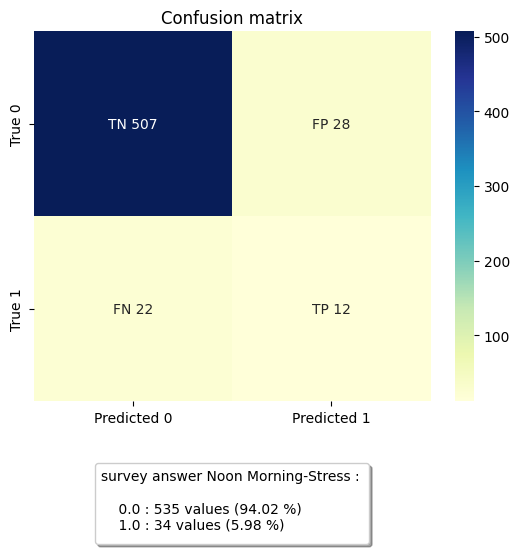

              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95       535
         1.0       0.30      0.35      0.32        34

    accuracy                           0.91       569
   macro avg       0.63      0.65      0.64       569
weighted avg       0.92      0.91      0.92       569



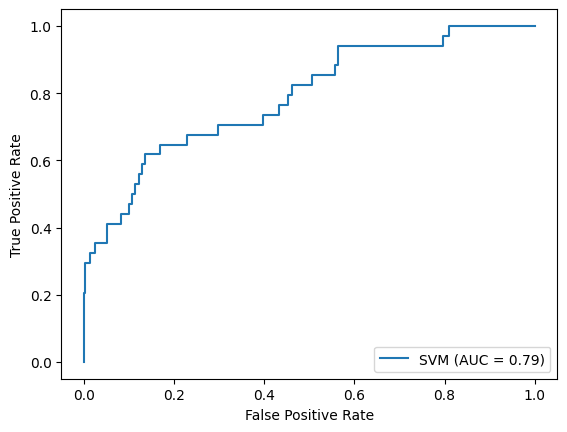

In [13]:
# Check model accurracy
check_confusion_matrix(y=y_test, y_pred=y_pred)
check_classification_report(y=y_test, y_pred=y_pred, print_bla_bla=False, print_as_text=True)
check_roc_auc(estimator=grid.best_estimator_, X_test=X_test, y_test=y_test)

#put this code after each model
dtc_cm = confusion_matrix(y_test, y_pred)
tp, fp, fn, tn = [item for sublist in dtc_cm.tolist() for item in sublist]
results.loc[len(results.index)] = ['Third SVM Hyperparameter Tuning', tp, fp, fn, tn,0] 

# Fourth experimentation :  Automatic feature selection
- Groups care 80/20 split train/test (A separation that takes individuals into account and ensures that a participant's data does not end up in the train and test sets)
- Standard data normalization
- ```clf = SVC(class_weight="balanced")``` + Hyperparameter Tuning : ```scoring_metric="f1_weighted"``` , ```inner_CV=StratifiedGroupKFold(n_splits=5)```
- Automatic feature selection :
    - eliminate the features with too little variability
    - those with too much correlation
    - finally we use a sequential selection until the model does not progress anymore.


[Eliminate participants with not enought data]
	 UUID 86, 20 lines --> removed participant
	 UUID 88, 8 lines --> removed participant

[Index cleaning] 
	 changes the multi-index of the columns to a simple index 
	 removes the multi-index of the rows 
		 timestamp and uuid becomes new columns

[Drop the unusable columns]
	 Dropped columns (96) : ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_ptp', 'acc_x_sum', 'acc_x_energy', 'acc_x_skewness', 'acc_x_kurtosis', 'acc_x_peaks', 'acc_x_rms', 'acc_x_lineintegral', 'acc_x_n_above_mean', 'acc_x_n_below_mean', 'acc_x_n_sign_changes', 'acc_x_iqr', 'acc_x_iqr_5_95', 'acc_x_pct_5', 'acc_x_pct_95', 'acc_x_entropy', 'acc_x_perm_entropy', 'acc_x_svd_entropy', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_ptp', 'acc_y_sum', 'acc_y_energy', 'acc_y_skewness', 'acc_y_kurtosis', 'acc_y_peaks', 'acc_y_rms', 'acc_y_lineintegral', 'acc_y_n_above_mean', 'acc_y_n_below_mean', 'acc_y_n_sign_changes', 'acc_y_iqr', 'acc_y_iqr_5_95',

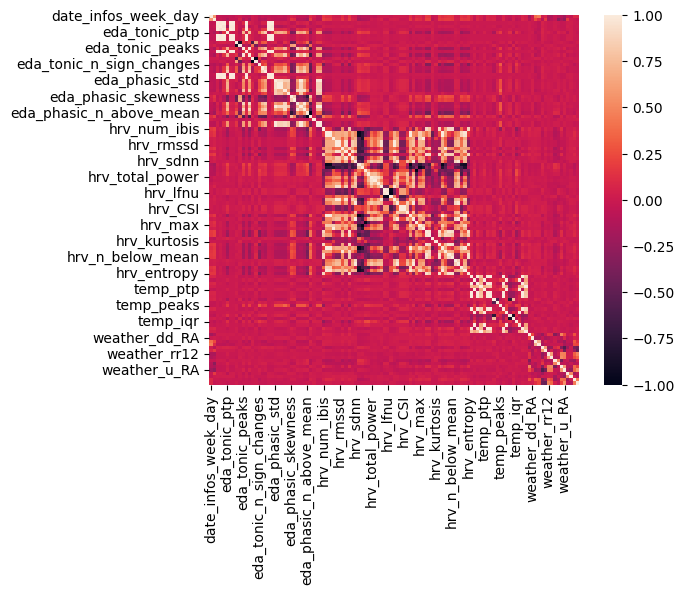


[Split data by taking care of the groups]
	 Train (80.08 %) : 
		 2287 lines 
		 0 : 2143 (93.7 %) 
		 1 : 144 (6.3 %)
	 Test (19.92 %) : 
		 569 lines 
		 0 : 535 (94.02 %) 
		 1 : 34 (5.98 %)

[Classic data normalization with StandardScaler]


[Sequential feature selection]
	 Direction : forward
	 Tol : 0.001
	 Columns to keep (77) : ['date_infos_week_day', 'date_infos_rest_day', 'eda_tonic_mean', 'eda_tonic_ptp', 'eda_tonic_skewness', 'eda_tonic_kurtosis', 'eda_tonic_peaks', 'eda_tonic_n_above_mean', 'eda_tonic_n_below_mean', 'eda_tonic_n_sign_changes', 'eda_tonic_iqr', 'eda_tonic_iqr_5_95', 'eda_phasic_std', 'eda_phasic_max', 'eda_phasic_sum', 'eda_phasic_energy', 'eda_phasic_skewness', 'eda_phasic_kurtosis', 'eda_phasic_peaks', 'eda_phasic_n_above_mean', 'eda_phasic_n_below_mean', 'eda_phasic_n_sign_changes', 'hrv_num_ibis', 'hrv_mean_nni', 'hrv_range_nni', 'hrv_sdsd', 'hrv_nni_50', 'hrv_pnni_50', 'hrv_nni_20', 'hrv_pnni_20', 'hrv_sdnn', 'hrv_mean_hr', 'hrv_min_hr', 'hrv_max_hr',

In [14]:
# Get X, y
X, y, groups, timestamps = get_X_y_groups_timestamps(
    target_column=selected_target_column,
    minimum_threshold_for_target_binarization=selected_minimum_threshold_for_target_binarization,
    maximum_threshold_for_target_binarization=selected_maximum_threshold_for_target_binarization,
)

# First little feature selection
X = variance_threshold_feature_selection(X=X) #Feature selector that removes all low-variance features - feature is approximately constant and will not improve the performance of the model
X = pairwise_correlation(X=X) #If multiple features are highly correlated, then they will not improve our classification performance

# Groups care 80/20 split train/test
X_train, X_test, y_train, y_test, groups_train, groups_test = get_group_cared_X_train_X_test_y_train_y_test(X=X, y=y, groups=groups)
# Standard normalization
X_train, X_test = classic_data_normalization(X_train=X_train, X_test=X_test)

# Second feature selection
#This Sequential Feature Selector adds (forward selection) or removes (backward selection) features to form a feature subset in a greedy fashion. At each stage, this estimator chooses the best feature to add or remove based on the cross-validation score of an estimator.
print("\n[Sequential feature selection]")
sfs = SequentialFeatureSelector(
    estimator=SVC(class_weight="balanced"),
    scoring=score_metric,
    n_features_to_select='auto',
    tol=0.001,
    direction="forward",
    cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=selected_random_state),
    n_jobs=-1
)
sfs.fit(X_train, y_train)
columns_to_keep = X.columns[sfs.get_support()]
print(f'\t Direction : {sfs.direction}')
print(f'\t Tol : {sfs.tol}')
print(f'\t Columns to keep ({len(columns_to_keep)}) : {columns_to_keep.to_list()}')
X_train = X_train[columns_to_keep]
X_test = X_test[columns_to_keep]


# Hyperparameters optimisation and classifier training
param_grid = {
        "kernel" : ["rbf"],
        "C" : [1, 2, 4, 8, 16, 32, 64, 128],
        "gamma" : ['auto', 'scale', 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001],
        "class_weight" : ["balanced"],
        "random_state" : [selected_random_state]
}
inner_CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=selected_random_state)
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring=score_metric,
    cv=inner_CV,
    verbose=3,
    n_jobs=-1,
)
fit_time_t1 = time()
grid.fit(X=X_train, y=y_train, groups=groups_train)
fit_time_t2 = time()
print("\n[GridSearch results]")
print(f"\t Fit in {round(fit_time_t2 - fit_time_t1, 2)} s")
print(f"\t Train best score : {round(grid.best_score_, 3)} ({grid.scoring})")
print(f"\t Best parameters set for {grid.estimator} :")
best_parameters = grid.best_estimator_.get_params()
for param_name in sorted(param_grid.keys()):
    print("\t\t %s : %r" % (param_name, best_parameters[param_name]))
# Predict on the test subset
y_pred = grid.best_estimator_.predict(X_test)

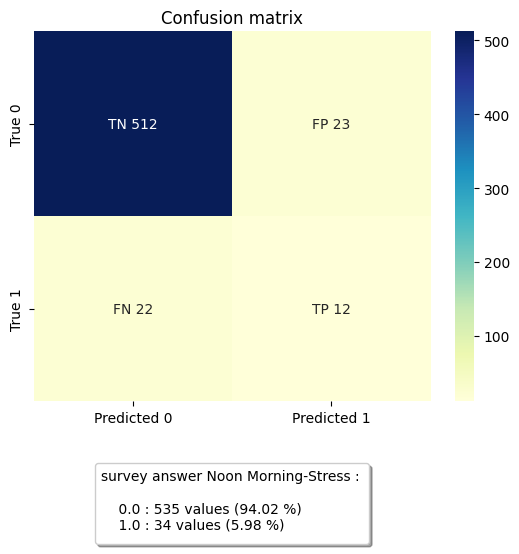

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       535
         1.0       0.34      0.35      0.35        34

    accuracy                           0.92       569
   macro avg       0.65      0.65      0.65       569
weighted avg       0.92      0.92      0.92       569



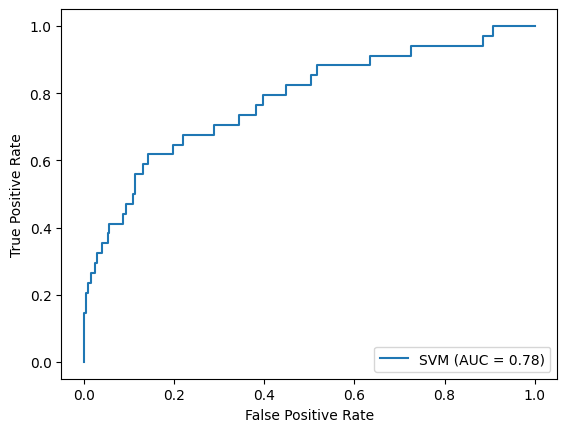

In [15]:
# Check model accurracy
check_confusion_matrix(y=y_test, y_pred=y_pred)
check_classification_report(y=y_test, y_pred=y_pred, print_bla_bla=False, print_as_text=True)
check_roc_auc(estimator=grid.best_estimator_, X_test=X_test, y_test=y_test)

#put this code after each model
dtc_cm = confusion_matrix(y_test, y_pred)
tp, fp, fn, tn = [item for sublist in dtc_cm.tolist() for item in sublist]
results.loc[len(results.index)] = ['Fourth Automatic feature selection', tp, fp, fn, tn,0] 

# Fifth experimentation : Special Data normalization
- Groups care 80/20 split train/test (A separation that takes individuals into account and ensures that a participant's data does not end up in the train and test sets)
- Data normalization according to a baseline established on all the nights of each participant
- ```clf = SVC(class_weight="balanced")``` + Hyperparameter Tuning : ```scoring_metric="f1_weighted"``` , ```inner_CV=StratifiedGroupKFold(n_splits=5)```
- Little automatic feature selection : 
    - eliminate the features with too little variability
    - with too much correlation


[Eliminate participants with not enought data]
	 UUID 86, 20 lines --> removed participant
	 UUID 88, 8 lines --> removed participant

[Index cleaning] 
	 changes the multi-index of the columns to a simple index 
	 removes the multi-index of the rows 
		 timestamp and uuid becomes new columns

[Drop the unusable columns]
	 Dropped columns (96) : ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_ptp', 'acc_x_sum', 'acc_x_energy', 'acc_x_skewness', 'acc_x_kurtosis', 'acc_x_peaks', 'acc_x_rms', 'acc_x_lineintegral', 'acc_x_n_above_mean', 'acc_x_n_below_mean', 'acc_x_n_sign_changes', 'acc_x_iqr', 'acc_x_iqr_5_95', 'acc_x_pct_5', 'acc_x_pct_95', 'acc_x_entropy', 'acc_x_perm_entropy', 'acc_x_svd_entropy', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_ptp', 'acc_y_sum', 'acc_y_energy', 'acc_y_skewness', 'acc_y_kurtosis', 'acc_y_peaks', 'acc_y_rms', 'acc_y_lineintegral', 'acc_y_n_above_mean', 'acc_y_n_below_mean', 'acc_y_n_sign_changes', 'acc_y_iqr', 'acc_y_iqr_5_95',

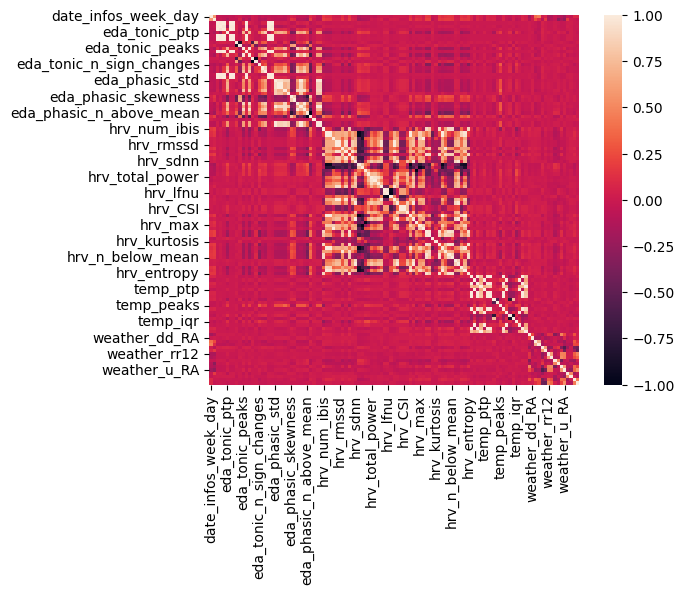

100%|██████████| 78/78 [00:22<00:00,  3.53it/s]



[Split data by taking care of the groups]
	 Train (80.08 %) : 
		 2287 lines 
		 0 : 2143 (93.7 %) 
		 1 : 144 (6.3 %)
	 Test (19.92 %) : 
		 569 lines 
		 0 : 535 (94.02 %) 
		 1 : 34 (5.98 %)

[Classic data normalization with StandardScaler]

Fitting 5 folds for each of 72 candidates, totalling 360 fits

[GridSearch results]
	 Fit in 30.13 s
	 Train best score : 0.933 (f1_weighted)
	 Best parameters set for SVC() :
		 C : 16
		 class_weight : 'balanced'
		 gamma : 'auto'
		 kernel : 'rbf'
		 random_state : 2022


In [16]:
# Get X, y
X, y, groups, timestamps = get_X_y_groups_timestamps(
    target_column=selected_target_column,
    minimum_threshold_for_target_binarization=selected_minimum_threshold_for_target_binarization,
    maximum_threshold_for_target_binarization=selected_maximum_threshold_for_target_binarization,
)

# First little feature selection
X = variance_threshold_feature_selection(X=X)
X = pairwise_correlation(X=X)
# Personnal data normalization
X = data_normalization_by_all_nights_average(X=X, groups=groups)
# Groups care 80/20 split train/test
X_train, X_test, y_train, y_test, groups_train, groups_test = get_group_cared_X_train_X_test_y_train_y_test(X=X, y=y, groups=groups)
# Standard normalization
X_train, X_test = classic_data_normalization(X_train=X_train, X_test=X_test)
# Hyperparameters optimisation and classifier training
param_grid = {
        "kernel" : ["rbf"],
        "C" : [1, 2, 4, 8, 16, 32, 64, 128],
        "gamma" : ['auto', 'scale', 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001],
        "class_weight" : ["balanced"],
        "random_state" : [selected_random_state]
}
inner_CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=selected_random_state)
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring=score_metric,
    cv=inner_CV,
    verbose=3,
    n_jobs=-1,
)
fit_time_t1 = time()
grid.fit(X=X_train, y=y_train, groups=groups_train)
fit_time_t2 = time()
print("\n[GridSearch results]")
print(f"\t Fit in {round(fit_time_t2 - fit_time_t1, 2)} s")
print(f"\t Train best score : {round(grid.best_score_, 3)} ({grid.scoring})")
print(f"\t Best parameters set for {grid.estimator} :")
best_parameters = grid.best_estimator_.get_params()
for param_name in sorted(param_grid.keys()):
    print("\t\t %s : %r" % (param_name, best_parameters[param_name]))
# Predict on the test subset
y_pred = grid.best_estimator_.predict(X_test)

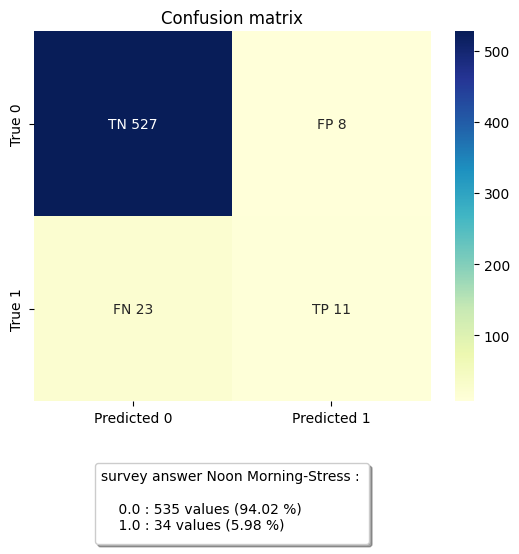

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97       535
         1.0       0.58      0.32      0.42        34

    accuracy                           0.95       569
   macro avg       0.77      0.65      0.69       569
weighted avg       0.94      0.95      0.94       569



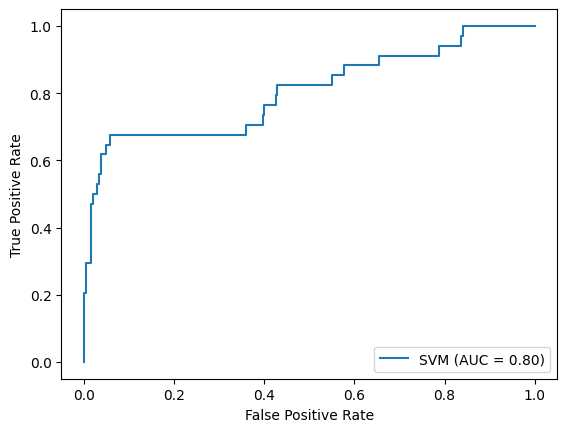

In [17]:
# Check model accurracy
check_confusion_matrix(y=y_test, y_pred=y_pred)
check_classification_report(y=y_test, y_pred=y_pred, print_bla_bla=False, print_as_text=True)
check_roc_auc(estimator=grid.best_estimator_, X_test=X_test, y_test=y_test)

#put this code after each model
dtc_cm = confusion_matrix(y_test, y_pred)
tp, fp, fn, tn = [item for sublist in dtc_cm.tolist() for item in sublist]
results.loc[len(results.index)] = ['Fifth Special Data normalization', tp, fp, fn, tn,0] 

# Sixth experimentation : Add data filtering
- Groups care 80/20 split train/test (A separation that takes individuals into account and ensures that a participant's data does not end up in the train and test sets)
- Data filtering according to a threshold
- Data normalization according to a baseline established on all the nights of each participant
- ```clf = SVC(class_weight="balanced")``` + Hyperparameter Tuning : ```scoring_metric="f1_weighted"``` , ```inner_CV=StratifiedGroupKFold(n_splits=5)```
- Little automatic feature selection : 
    - eliminate the features with too little variability
    - with too much correlation


[Eliminate participants with not enought data]
	 UUID 86, 20 lines --> removed participant
	 UUID 88, 8 lines --> removed participant

[Index cleaning] 
	 changes the multi-index of the columns to a simple index 
	 removes the multi-index of the rows 
		 timestamp and uuid becomes new columns

[Drop the unusable columns]
	 Dropped columns (96) : ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_ptp', 'acc_x_sum', 'acc_x_energy', 'acc_x_skewness', 'acc_x_kurtosis', 'acc_x_peaks', 'acc_x_rms', 'acc_x_lineintegral', 'acc_x_n_above_mean', 'acc_x_n_below_mean', 'acc_x_n_sign_changes', 'acc_x_iqr', 'acc_x_iqr_5_95', 'acc_x_pct_5', 'acc_x_pct_95', 'acc_x_entropy', 'acc_x_perm_entropy', 'acc_x_svd_entropy', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_ptp', 'acc_y_sum', 'acc_y_energy', 'acc_y_skewness', 'acc_y_kurtosis', 'acc_y_peaks', 'acc_y_rms', 'acc_y_lineintegral', 'acc_y_n_above_mean', 'acc_y_n_below_mean', 'acc_y_n_sign_changes', 'acc_y_iqr', 'acc_y_iqr_5_95',

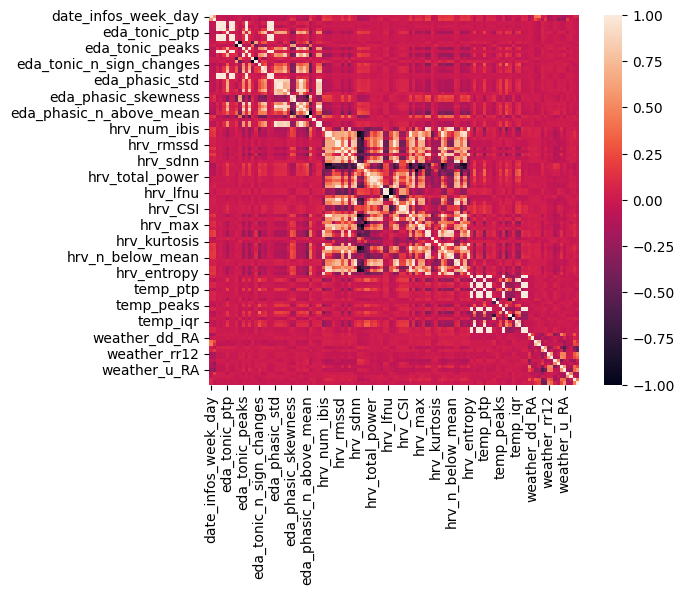

100%|██████████| 79/79 [00:11<00:00,  7.12it/s]



[Split data by taking care of the groups]
	 Train (80.05 %) : 
		 2143 lines 
		 0 : 2016 (94.07 %) 
		 1 : 127 (5.93 %)
	 Test (19.95 %) : 
		 534 lines 
		 0 : 503 (94.19 %) 
		 1 : 31 (5.81 %)

[Classic data normalization with StandardScaler]

Fitting 5 folds for each of 72 candidates, totalling 360 fits

[GridSearch results]
	 Fit in 25.63 s
	 Train best score : 0.935 (f1_weighted)
	 Best parameters set for SVC() :
		 C : 8
		 class_weight : 'balanced'
		 gamma : 'auto'
		 kernel : 'rbf'
		 random_state : 2022


In [18]:
# Get X, y
X, y, groups, timestamps = get_X_y_groups_timestamps(
    target_column=selected_target_column,
    minimum_threshold_for_target_binarization=selected_minimum_threshold_for_target_binarization,
    maximum_threshold_for_target_binarization=selected_maximum_threshold_for_target_binarization,
)
# Data filtration
X, y, groups, timestamps = filter_the_data_according_to_the_accelerometer(
    X=X,
    y=y,
    groups=groups,
    timestamps=timestamps,
    acc_column="acc_l2_lineintegral",
    threshold=0.552 * 10**6, 
    threshold_is_the_max_value=True,
)
# Features selection
X = variance_threshold_feature_selection(X=X)
X = pairwise_correlation(X=X)
# Personnal data normalization
X = data_normalization_by_all_nights_average(X=X, groups=groups)
# Groups care 80/20 split train/test
X_train, X_test, y_train, y_test, groups_train, groups_test = get_group_cared_X_train_X_test_y_train_y_test(X=X, y=y, groups=groups)
# Standard normalization
X_train, X_test = classic_data_normalization(X_train=X_train, X_test=X_test)
# Hyperparameters optimisation and classifier training
param_grid = {
        "kernel" : ["rbf"],
        "C" : [1, 2, 4, 8, 16, 32, 64, 128],
        "gamma" : ['auto', 'scale', 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001],
        "class_weight" : ["balanced"],
        "random_state" : [selected_random_state]
}
inner_CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=selected_random_state)
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring=score_metric,
    cv=inner_CV,
    verbose=3,
    n_jobs=-1,
)
fit_time_t1 = time()
grid.fit(X=X_train, y=y_train, groups=groups_train)
fit_time_t2 = time()
print("\n[GridSearch results]")
print(f"\t Fit in {round(fit_time_t2 - fit_time_t1, 2)} s")
print(f"\t Train best score : {round(grid.best_score_, 3)} ({grid.scoring})")
print(f"\t Best parameters set for {grid.estimator} :")
best_parameters = grid.best_estimator_.get_params()
for param_name in sorted(param_grid.keys()):
    print("\t\t %s : %r" % (param_name, best_parameters[param_name]))
# Predict on the test subset
y_pred = grid.best_estimator_.predict(X_test)

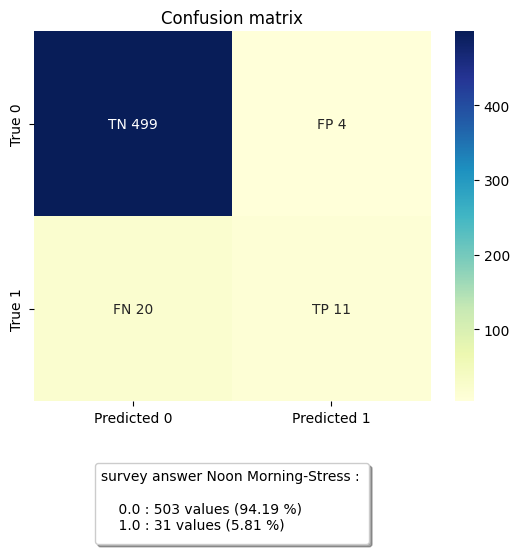

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98       503
         1.0       0.73      0.35      0.48        31

    accuracy                           0.96       534
   macro avg       0.85      0.67      0.73       534
weighted avg       0.95      0.96      0.95       534



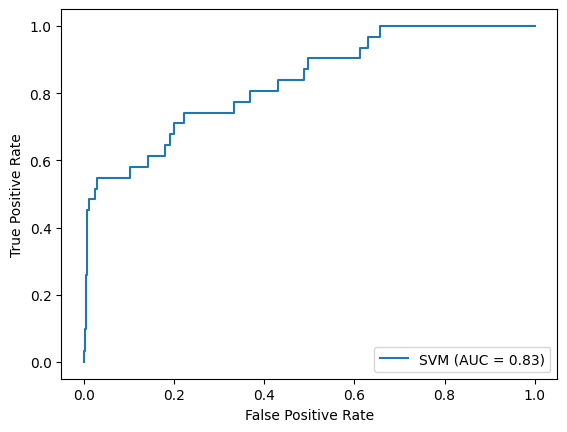

In [19]:
# Check model accurracy
check_confusion_matrix(y=y_test, y_pred=y_pred)
check_classification_report(y=y_test, y_pred=y_pred, print_bla_bla=False, print_as_text=True)
check_roc_auc(estimator=grid.best_estimator_, X_test=X_test, y_test=y_test)

#put this code after each model
dtc_cm = confusion_matrix(y_test, y_pred)
tp, fp, fn, tn = [item for sublist in dtc_cm.tolist() for item in sublist]
results.loc[len(results.index)] = ['Sixth Add data filtering', tp, fp, fn, tn,0] 

# Seventh experimentation : Use the on demand forms 

| WARNING : For this experiment we use the stress scores from the on-demand forms. |
| --- |

- Groups care 80/20 split train/test (A separation that takes individuals into account and ensures that a participant's data does not end up in the train and test sets)
- Standard data normalization
- ```clf = SVC(class_weight="balanced")``` + Hyperparameter Tuning : ```scoring_metric="f1_weighted"``` , ```inner_CV=StratifiedGroupKFold(n_splits=5)```
- Little automatic feature selection : 
    - eliminate the features with too little variability
    - with too much correlation

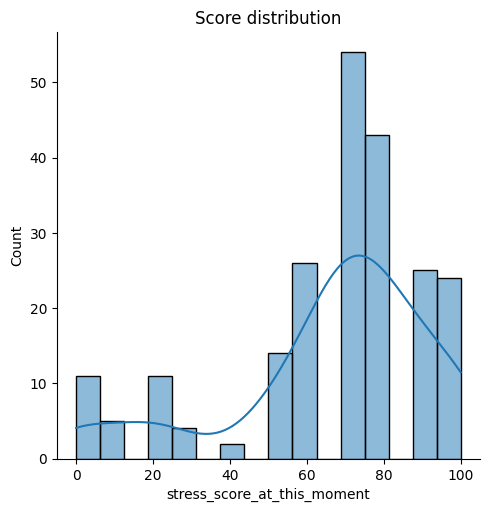

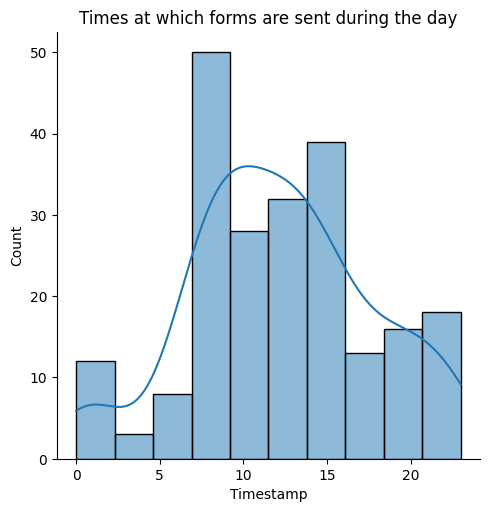

In [20]:
# plot distribution
on_demand_survey_distribution()


[Remove columns with infinite values]
	 36481 infinite values found in eda_tonic_entropy (81.6 %) -> column droped
	 33771 infinite values found in eda_phasic_entropy (75.54 %) -> column droped

[Remove columns with infinite values]
	 36481 infinite values found in eda_tonic_entropy (81.6 %) -> column droped
	 33771 infinite values found in eda_phasic_entropy (75.54 %) -> column droped

[transform_on_demand_survey_df_multiindex_to_fit_the_full_hours]
	 61 on_demand_survey did not find an equivalent in the original dataframe
	 158 remaining

[on_demand_Stress_Score distribution after binarization]
	 1.0 : 128 (88.28 %)
	 0.0 : 17 (11.72 %)


No more zen situation available for 88

[The Stress_Score column after adding 0]
	 1.0 : 128 (50.2 %)
	 0.0 : 127 (49.8 %)



[Variance Threshold Feature Selection]
	 Droped columns (18): ['date_infos_end_of_year_exam', 'eda_tonic_perm_entropy', 'eda_tonic_svd_entropy', 'eda_phasic_min', 'eda_phasic_pct_5', 'eda_phasic_perm_entropy', 'eda_phasic_sv

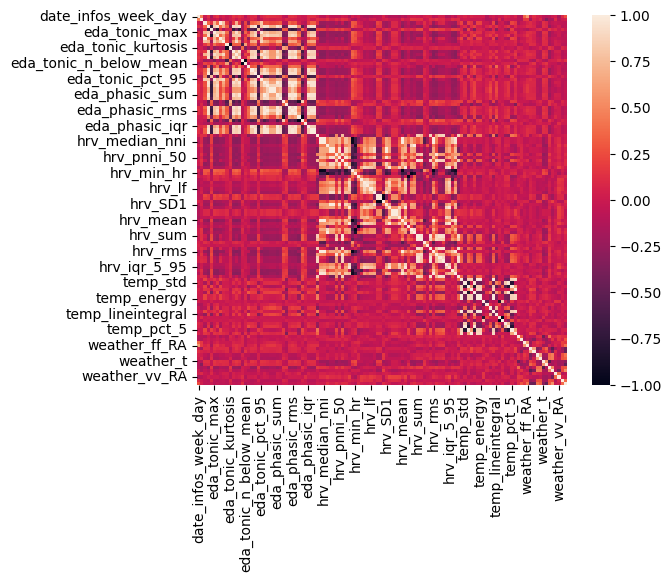


[Split data by taking care of the groups]
	 Train (78.82 %) : 
		 201 lines 
		 0 : 98 (48.76 %) 
		 1 : 103 (51.24 %)
	 Test (21.18 %) : 
		 54 lines 
		 0 : 29 (53.7 %) 
		 1 : 25 (46.3 %)

[Classic data normalization with StandardScaler]

Fitting 5 folds for each of 72 candidates, totalling 360 fits

[GridSearch results]
	 Fit in 1.94 s
	 Train best score : 0.69 (f1_weighted)
	 Best parameters set for SVC() :
		 C : 8
		 class_weight : 'balanced'
		 gamma : 0.001
		 kernel : 'rbf'
		 random_state : 2022


In [21]:
# Get X, y
X, y, groups, timestamps = get_X_y_groups_timestamps_especially_for_on_demand_survey(
        add_0_artificially=True,
        min_binarization=20,
        max_binarization=60
)
# Little feature selection
X = variance_threshold_feature_selection(X=X)
X = pairwise_correlation(X=X)
# Groups care 80/20 split train/test
X_train, X_test, y_train, y_test, groups_train, groups_test = get_group_cared_X_train_X_test_y_train_y_test(X=X, y=y, groups=groups)
# Standard normalization
X_train, X_test = classic_data_normalization(X_train=X_train, X_test=X_test)
# Hyperparameters optimisation and classifier training
param_grid = {
        "kernel" : ["rbf"],
        "C" : [1, 2, 4, 8, 16, 32, 64, 128],
        "gamma" : ['auto', 'scale', 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001],
        "class_weight" : ["balanced"],
        "random_state" : [selected_random_state]
}
inner_CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=selected_random_state)
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring=score_metric,
    cv=inner_CV,
    verbose=3,
    n_jobs=-1,
)
fit_time_t1 = time()
grid.fit(X=X_train, y=y_train, groups=groups_train)
fit_time_t2 = time()
print("\n[GridSearch results]")
print(f"\t Fit in {round(fit_time_t2 - fit_time_t1, 2)} s")
print(f"\t Train best score : {round(grid.best_score_, 3)} ({grid.scoring})")
print(f"\t Best parameters set for {grid.estimator} :")
best_parameters = grid.best_estimator_.get_params()
for param_name in sorted(param_grid.keys()):
    print("\t\t %s : %r" % (param_name, best_parameters[param_name]))
# Predict on the test subset
y_pred = grid.best_estimator_.predict(X_test)

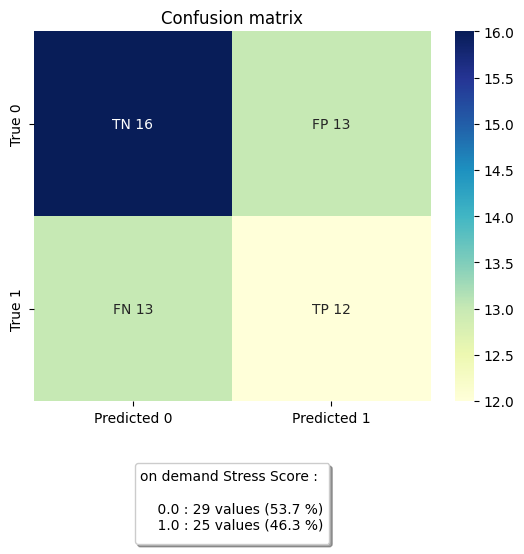

              precision    recall  f1-score   support

         0.0       0.55      0.55      0.55        29
         1.0       0.48      0.48      0.48        25

    accuracy                           0.52        54
   macro avg       0.52      0.52      0.52        54
weighted avg       0.52      0.52      0.52        54



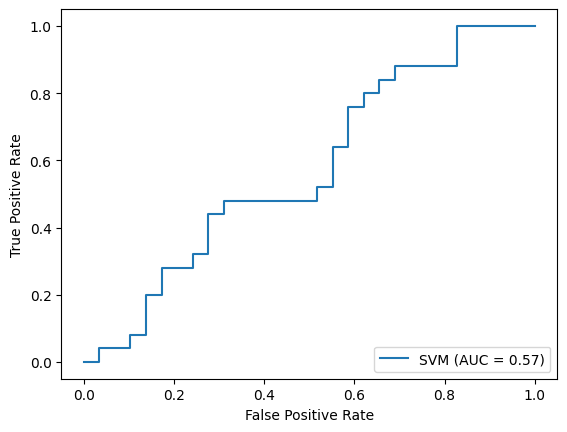

In [22]:
# Check model accurracy
check_confusion_matrix(y=y_test, y_pred=y_pred)
check_classification_report(y=y_test, y_pred=y_pred, print_bla_bla=False, print_as_text=True)
check_roc_auc(estimator=grid.best_estimator_, X_test=X_test, y_test=y_test)

#put this code after each model
dtc_cm = confusion_matrix(y_test, y_pred)
tp, fp, fn, tn = [item for sublist in dtc_cm.tolist() for item in sublist]
results.loc[len(results.index)] = ['Seventh Use the on demand forms', tp, fp, fn, tn,0] 

In [23]:
#at the end run this code to calculate the accuracy and printn the tabel of results
results['Accuracy'] = (results['TP']+results['TN'])/(results['TP']+results['FP']+results['FN']+results['TN'])
results = results.sort_values(by='Accuracy', ascending=False)
results


#True Positive (TP) — A true positive is an outcome where the model correctly predicts the positive class.
#True Negative (TN) — A true negative is an outcome where the model correctly predicts the negative class.
#False Positive (FP) — A false positive is an outcome where the model incorrectly predicts the positive class.
#False Negative (FN) — A false negative is an outcome where the model incorrectly predicts the negative class.

,Model,TP,FP,FN,TN,Accuracy
5,Sixth Add data filtering,499,4,20,11,0.955056
4,Fifth Special Data normalization,527,8,23,11,0.945518
0,first basic,503,33,9,27,0.926573
3,Fourth Automatic feature selection,512,23,22,12,0.920914
2,Third SVM Hyperparameter Tuning,507,28,22,12,0.912127
1,second Special split train/test,473,62,16,18,0.862917
6,Seventh Use the on demand forms,16,13,13,12,0.518519
